# Valorant Agent Recommendation System
#
# This notebook implements a machine learning system that recommends the top 3 agents for a given map and role.
# The system uses ACS (Average Combat Score) prediction and provides explainability for each recommendation.
#
# ## Key Improvements with game_id and date:
# 1. **Proper Temporal Ordering**: Uses actual dates instead of row indices for chronological sorting
# 2. **Time-based Features**: Extracts day of week, month, and time-since patterns
# 3. **Realistic Evaluation**: Temporal train-test split (train on past, test on future)
# 4. **Better Rolling Metrics**: Accurate calculation of rolling averages based on actual game sequence
# 5. **Recency Weighting**: Can identify performance trends over time
# 6. **Seasonality Detection**: Captures day-of-week and monthly performance patterns


In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries imported successfully!")


## 1. Data Loading and Initial Exploration


In [2]:
# Load the cleaned dataset
data_path = r'C:\Users\prith\IdeaProjects\Valorant_Agent_Predictor\data\processed\player_game_data_cleaned.csv'
df = pd.read_csv(data_path)

# Convert date to datetime for time-series features
df['date'] = pd.to_datetime(df['date'], format='%m/%d/%Y')

# Sort by game_id and date to ensure chronological order
df = df.sort_values(['game_id', 'date']).reset_index(drop=True)

print("Dataset shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nData types:")
print(df.dtypes)
print("\nBasic statistics:")
print(df.describe())
print(f"\nDate range: {df['date'].min()} to {df['date'].max()}")


Dataset shape: (1296, 13)

First few rows:
   game_id       date      agent     map outcome  round_wins  round_losses  \
0        1 2023-04-11     Cypher  Ascent    Loss           5            13   
1        2 2023-04-12     Cypher  Icebox    Loss           4            13   
2        3 2023-04-15      KAY/O   Lotus     Win          13             4   
3        4 2023-04-15  Brimstone  Ascent    Loss           9            13   
4        5 2023-04-15     Cypher   Haven    Loss           1            13   

   kills  deaths  assists       kdr  acs        role  
0      8      15        4  0.533333  125    Sentinel  
1      3      15        2  0.200000   59    Sentinel  
2      7      12        7  0.583333  132   Initiator  
3     18      12       10  1.500000  230  Controller  
4      6      14        3  0.428571  146    Sentinel  

Data types:
game_id                  int64
date            datetime64[us]
agent                      str
map                        str
outcome              

In [3]:
# Check unique values for categorical features
print("Unique Agents:", df['agent'].nunique())
print(df['agent'].unique())
print("\nUnique Maps:", df['map'].nunique())
print(df['map'].unique())
print("\nUnique Roles:", df['role'].nunique())
print(df['role'].unique())
print("\nOutcome distribution:")
print(df['outcome'].value_counts())


Unique Agents: 11
<StringArray>
[   'Cypher',     'KAY/O', 'Brimstone',   'Phoenix',    'Breach',   'Killjoy',
     'Viper',      'Omen',      'Fade',      'Vyse',     'Astra']
Length: 11, dtype: str

Unique Maps: 11
<StringArray>
[  'Ascent',   'Icebox',    'Lotus',    'Haven',    'Pearl', 'Fracture',
    'Split',     'Bind',   'Breeze',   'Sunset',    'Abyss']
Length: 11, dtype: str

Unique Roles: 4
<StringArray>
['Sentinel', 'Initiator', 'Controller', 'Duelist']
Length: 4, dtype: str

Outcome distribution:
outcome
Win     629
Loss    610
Draw     57
Name: count, dtype: int64


## 2. Feature Engineering


In [4]:
# Create a copy for feature engineering
df_fe = df.copy()

# Use game_id for chronological ordering (already sorted)
# The data is now sorted by game_id and date, ensuring proper time series

# Extract time-based features from date
df_fe['day_of_week'] = df_fe['date'].dt.dayofweek  # 0=Monday, 6=Sunday
df_fe['month'] = df_fe['date'].dt.month
df_fe['days_since_start'] = (df_fe['date'] - df_fe['date'].min()).dt.days

# Calculate days since last match for recency weighting
df_fe['days_since_last_match'] = df_fe['date'].diff().dt.days.fillna(0)

print("Time-based features created!")
print(f"Date range: {df_fe['date'].min()} to {df_fe['date'].max()}")
print(f"Total days span: {df_fe['days_since_start'].max()} days")

# Basic engineered features
df_fe['total_rounds'] = df_fe['round_wins'] + df_fe['round_losses']

# Safe division to avoid division by zero
df_fe['win_rate'] = np.where(df_fe['total_rounds'] > 0,
                              df_fe['round_wins'] / df_fe['total_rounds'],
                              0)
df_fe['kill_assist_ratio'] = np.where(df_fe['total_rounds'] > 0,
                                       (df_fe['kills'] + df_fe['assists']) / df_fe['total_rounds'],
                                       0)
df_fe['acs_per_round'] = np.where(df_fe['total_rounds'] > 0,
                                   df_fe['acs'] / df_fe['total_rounds'],
                                   0)

# Damage participation (normalized)
df_fe['damage_participation'] = (df_fe['kills'] + df_fe['assists']) / (df_fe['kills'] + df_fe['assists'] + df_fe['deaths'] + 1)

# Combat efficiency
df_fe['combat_efficiency'] = df_fe['kills'] - df_fe['deaths']

# Create outcome numeric (for win rate calculations)
df_fe['outcome_numeric'] = df_fe['outcome'].map({'Win': 1, 'Loss': 0, 'Draw': 0.5})

print("\nBasic features created!")
print("\nNew features:")
print(df_fe[['game_id', 'date', 'total_rounds', 'win_rate', 'kill_assist_ratio', 'acs_per_round', 'day_of_week', 'days_since_last_match']].head())


Time-based features created!
Date range: 2023-04-11 00:00:00 to 2026-03-15 00:00:00
Total days span: 1069 days

Basic features created!

New features:
   game_id       date  total_rounds  win_rate  kill_assist_ratio  \
0        1 2023-04-11            18  0.277778           0.666667   
1        2 2023-04-12            17  0.235294           0.294118   
2        3 2023-04-15            17  0.764706           0.823529   
3        4 2023-04-15            22  0.409091           1.272727   
4        5 2023-04-15            14  0.071429           0.642857   

   acs_per_round  day_of_week  days_since_last_match  
0       6.944444            1                    0.0  
1       3.470588            2                    1.0  
2       7.764706            5                    3.0  
3      10.454545            5                    0.0  
4      10.428571            5                    0.0  


In [5]:
# Rolling average features (last 5 matches)
rolling_window = 5

# Data is already sorted by game_id and date, ensuring chronological order
# Calculate rolling averages
df_fe['acs_rolling_5'] = df_fe['acs'].rolling(window=rolling_window, min_periods=1).mean()
df_fe['kdr_rolling_5'] = df_fe['kdr'].rolling(window=rolling_window, min_periods=1).mean()
df_fe['kills_rolling_5'] = df_fe['kills'].rolling(window=rolling_window, min_periods=1).mean()
df_fe['assists_rolling_5'] = df_fe['assists'].rolling(window=rolling_window, min_periods=1).mean()
df_fe['win_rate_rolling_5'] = df_fe['outcome_numeric'].rolling(window=rolling_window, min_periods=1).mean()

# Lag features (previous match performance)
df_fe['acs_lag_1'] = df_fe['acs'].shift(1).fillna(df_fe['acs'].mean())
df_fe['kdr_lag_1'] = df_fe['kdr'].shift(1).fillna(df_fe['kdr'].mean())

# Recent performance variance (helps identify consistency)
df_fe['acs_rolling_std_5'] = df_fe['acs'].rolling(window=rolling_window, min_periods=2).std().fillna(0)
df_fe['kdr_rolling_std_5'] = df_fe['kdr'].rolling(window=rolling_window, min_periods=2).std().fillna(0)

print("Rolling average features created!")
print("\nRolling features sample:")
print(df_fe[['game_id', 'date', 'acs', 'acs_rolling_5', 'acs_rolling_std_5', 'acs_lag_1', 'kdr', 'kdr_rolling_5']].head(10))


Rolling average features created!

Rolling features sample:
   game_id       date  acs  acs_rolling_5  acs_rolling_std_5   acs_lag_1  \
0        1 2023-04-11  125     125.000000           0.000000  192.070988   
1        2 2023-04-12   59      92.000000          46.669048  125.000000   
2        3 2023-04-15  132     105.333333          40.278199   59.000000   
3        4 2023-04-15  230     136.500000          70.476947  132.000000   
4        5 2023-04-15  146     138.400000          61.182514  230.000000   
5        6 2023-04-15  234     160.200000          73.411171  146.000000   
6        7 2023-04-15  145     177.400000          50.167719  234.000000   
7        8 2023-04-15  119     174.800000          53.345103  145.000000   
8        9 2023-04-16  160     160.800000          43.516663  119.000000   
9       10 2023-04-16  284     188.400000          68.420026  160.000000   

        kdr  kdr_rolling_5  
0  0.533333       0.533333  
1  0.200000       0.366667  
2  0.583333     

In [6]:
# Agent-specific performance metrics
agent_stats = df_fe.groupby('agent').agg({
    'acs': ['mean', 'std'],
    'kdr': ['mean', 'std'],
    'win_rate': 'mean'
}).reset_index()
agent_stats.columns = ['agent', 'agent_acs_mean', 'agent_acs_std', 'agent_kdr_mean', 'agent_kdr_std', 'agent_win_rate']

df_fe = df_fe.merge(agent_stats, on='agent', how='left')

# Map-specific performance metrics
map_stats = df_fe.groupby('map').agg({
    'acs': ['mean', 'std'],
    'kdr': ['mean', 'std']
}).reset_index()
map_stats.columns = ['map', 'map_acs_mean', 'map_acs_std', 'map_kdr_mean', 'map_kdr_std']

df_fe = df_fe.merge(map_stats, on='map', how='left')

# Role-specific performance metrics
role_stats = df_fe.groupby('role').agg({
    'acs': ['mean', 'std'],
    'kdr': ['mean', 'std']
}).reset_index()
role_stats.columns = ['role', 'role_acs_mean', 'role_acs_std', 'role_kdr_mean', 'role_kdr_std']

df_fe = df_fe.merge(role_stats, on='role', how='left')

print("Agent/Map/Role statistics merged!")
print("\nDataset shape after feature engineering:", df_fe.shape)


Agent/Map/Role statistics merged!

Dataset shape after feature engineering: (1296, 46)


In [7]:
# Agent-Map performance metrics (interaction features)
agent_map_stats = df_fe.groupby(['agent', 'map']).agg({
    'acs': ['mean', 'count'],
    'kdr': 'mean',
    'win_rate': 'mean'
}).reset_index()
agent_map_stats.columns = ['agent', 'map', 'agent_map_acs_mean', 'agent_map_count', 'agent_map_kdr_mean', 'agent_map_win_rate']

df_fe = df_fe.merge(agent_map_stats, on=['agent', 'map'], how='left')

# Agent-Role performance (should be consistent but useful for validation)
agent_role_stats = df_fe.groupby(['agent', 'role']).agg({
    'acs': 'mean',
    'kdr': 'mean'
}).reset_index()
agent_role_stats.columns = ['agent', 'role', 'agent_role_acs_mean', 'agent_role_kdr_mean']

df_fe = df_fe.merge(agent_role_stats, on=['agent', 'role'], how='left')

print("Interaction features created!")
print("\nFinal dataset shape:", df_fe.shape)
print("\nSample of interaction features:")
print(df_fe[['agent', 'map', 'agent_map_acs_mean', 'agent_map_count', 'agent_map_win_rate']].head())


Interaction features created!

Final dataset shape: (1296, 52)

Sample of interaction features:
       agent     map  agent_map_acs_mean  agent_map_count  agent_map_win_rate
0     Cypher  Ascent          194.222222               99            0.500198
1     Cypher  Icebox          189.148148               27            0.494733
2      KAY/O   Lotus          133.333333                6            0.597243
3  Brimstone  Ascent          190.000000                3            0.361760
4     Cypher   Haven          196.550000               60            0.456400


## 3. Encode Categorical Variables


In [8]:
# Create label encoders
le_agent = LabelEncoder()
le_map = LabelEncoder()
le_role = LabelEncoder()

# Encode categorical features
df_fe['agent_encoded'] = le_agent.fit_transform(df_fe['agent'])
df_fe['map_encoded'] = le_map.fit_transform(df_fe['map'])
df_fe['role_encoded'] = le_role.fit_transform(df_fe['role'])

# Store mappings for later use
agent_mapping = dict(zip(le_agent.classes_, le_agent.transform(le_agent.classes_)))
map_mapping = dict(zip(le_map.classes_, le_map.transform(le_map.classes_)))
role_mapping = dict(zip(le_role.classes_, le_role.transform(le_role.classes_)))

print("Categorical variables encoded!")
print("\nAgent mapping:", agent_mapping)
print("\nMap mapping:", map_mapping)
print("\nRole mapping:", role_mapping)


Categorical variables encoded!

Agent mapping: {'Astra': np.int64(0), 'Breach': np.int64(1), 'Brimstone': np.int64(2), 'Cypher': np.int64(3), 'Fade': np.int64(4), 'KAY/O': np.int64(5), 'Killjoy': np.int64(6), 'Omen': np.int64(7), 'Phoenix': np.int64(8), 'Viper': np.int64(9), 'Vyse': np.int64(10)}

Map mapping: {'Abyss': np.int64(0), 'Ascent': np.int64(1), 'Bind': np.int64(2), 'Breeze': np.int64(3), 'Fracture': np.int64(4), 'Haven': np.int64(5), 'Icebox': np.int64(6), 'Lotus': np.int64(7), 'Pearl': np.int64(8), 'Split': np.int64(9), 'Sunset': np.int64(10)}

Role mapping: {'Controller': np.int64(0), 'Duelist': np.int64(1), 'Initiator': np.int64(2), 'Sentinel': np.int64(3)}


## 4. Prepare Features for Modeling


In [9]:
# Define feature columns
feature_columns = [
    'agent_encoded', 'map_encoded', 'role_encoded',
    'round_wins', 'round_losses', 'total_rounds',
    'kills', 'deaths', 'assists', 'kdr',
    'win_rate', 'kill_assist_ratio', 'acs_per_round',
    'damage_participation', 'combat_efficiency',
    'acs_rolling_5', 'kdr_rolling_5', 'kills_rolling_5', 'assists_rolling_5', 'win_rate_rolling_5',
    'acs_lag_1', 'kdr_lag_1',
    'acs_rolling_std_5', 'kdr_rolling_std_5',  # New variance features
    'day_of_week', 'month', 'days_since_start', 'days_since_last_match',  # New time-based features
    'agent_acs_mean', 'agent_acs_std', 'agent_kdr_mean', 'agent_kdr_std', 'agent_win_rate',
    'map_acs_mean', 'map_acs_std', 'map_kdr_mean', 'map_kdr_std',
    'role_acs_mean', 'role_acs_std', 'role_kdr_mean', 'role_kdr_std',
    'agent_map_acs_mean', 'agent_map_count', 'agent_map_kdr_mean', 'agent_map_win_rate',
    'agent_role_acs_mean', 'agent_role_kdr_mean'
]

# Target variable
target = 'acs'

# Prepare X and y
X = df_fe[feature_columns].copy()
y = df_fe[target].copy()

# Handle any remaining missing values and infinite values
print("Cleaning data...")
print(f"Initial inf values: {np.isinf(X.values).sum()}")
print(f"Initial nan values: {X.isna().sum().sum()}")

# Replace infinite values with NaN first
X = X.replace([np.inf, -np.inf], np.nan)

# Fill NaN values with column means
X = X.fillna(X.mean())

# Final check - if any columns still have NaN (e.g., all values were NaN), fill with 0
X = X.fillna(0)

print(f"After cleaning - inf values: {np.isinf(X.values).sum()}")
print(f"After cleaning - nan values: {X.isna().sum().sum()}")

print("\nFeatures prepared!")
print(f"\nNumber of features: {len(feature_columns)}")
print(f"Number of samples: {len(X)}")
print(f"\nTarget variable: {target}")
print(f"Target statistics:\n{y.describe()}")


Cleaning data...
Initial inf values: 0
Initial nan values: 0
After cleaning - inf values: 0
After cleaning - nan values: 0

Features prepared!

Number of features: 47
Number of samples: 1296

Target variable: acs
Target statistics:
count    1296.000000
mean      192.070988
std        68.818622
min         0.000000
25%       152.000000
50%       195.000000
75%       236.250000
max       572.000000
Name: acs, dtype: float64


## 5. Train-Test Split (Temporal)


In [10]:
# Use temporal split: train on older data, test on recent data
# This is more realistic - we predict future performance based on past data

# Sort by game_id to ensure chronological order
split_idx = int(len(X) * 0.8)

X_train = X.iloc[:split_idx].copy()
X_test = X.iloc[split_idx:].copy()
y_train = y.iloc[:split_idx].copy()
y_test = y.iloc[split_idx:].copy()

# Get the corresponding dates for information
train_dates = df_fe.iloc[:split_idx]['date']
test_dates = df_fe.iloc[split_idx:]['date']

print("Temporal Train-Test Split")
print("="*60)
print(f"Training set size: {len(X_train)} matches")
print(f"  Date range: {train_dates.min()} to {train_dates.max()}")
print(f"  Duration: {(train_dates.max() - train_dates.min()).days} days")
print(f"\nTest set size: {len(X_test)} matches")
print(f"  Date range: {test_dates.min()} to {test_dates.max()}")
print(f"  Duration: {(test_dates.max() - test_dates.min()).days} days")
print(f"\nTraining target range: {y_train.min():.2f} - {y_train.max():.2f}")
print(f"Test target range: {y_test.min():.2f} - {y_test.max():.2f}")

# Also preserve the indices for later analysis
train_indices = X_train.index
test_indices = X_test.index



Temporal Train-Test Split
Training set size: 1036 matches
  Date range: 2023-04-11 00:00:00 to 2026-03-14 00:00:00
  Duration: 1068 days

Test set size: 260 matches
  Date range: 2023-04-15 00:00:00 to 2026-03-15 00:00:00
  Duration: 1065 days

Training target range: 12.00 - 572.00
Test target range: 0.00 - 300.00


## 6. Model Training - Random Forest


In [11]:
# Train Random Forest Regressor
print("Training Random Forest Regressor...")
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# Predictions
y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)

# Evaluation
train_mae_rf = mean_absolute_error(y_train, y_train_pred_rf)
test_mae_rf = mean_absolute_error(y_test, y_test_pred_rf)
train_rmse_rf = np.sqrt(mean_squared_error(y_train, y_train_pred_rf))
test_rmse_rf = np.sqrt(mean_squared_error(y_test, y_test_pred_rf))
train_r2_rf = r2_score(y_train, y_train_pred_rf)
test_r2_rf = r2_score(y_test, y_test_pred_rf)

print("\nRandom Forest Results:")
print(f"Train MAE: {train_mae_rf:.2f}")
print(f"Test MAE: {test_mae_rf:.2f}")
print(f"Train RMSE: {train_rmse_rf:.2f}")
print(f"Test RMSE: {test_rmse_rf:.2f}")
print(f"Train R²: {train_r2_rf:.4f}")
print(f"Test R²: {test_r2_rf:.4f}")


Training Random Forest Regressor...

Random Forest Results:
Train MAE: 3.88
Test MAE: 47.41
Train RMSE: 8.51
Test RMSE: 60.34
Train R²: 0.9789
Test R²: 0.5102


## 7. Model Training - XGBoost


In [12]:
# Train XGBoost Regressor
print("Training XGBoost Regressor...")
xgb_model = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

# Predictions
y_train_pred_xgb = xgb_model.predict(X_train)
y_test_pred_xgb = xgb_model.predict(X_test)

# Evaluation
train_mae_xgb = mean_absolute_error(y_train, y_train_pred_xgb)
test_mae_xgb = mean_absolute_error(y_test, y_test_pred_xgb)
train_rmse_xgb = np.sqrt(mean_squared_error(y_train, y_train_pred_xgb))
test_rmse_xgb = np.sqrt(mean_squared_error(y_test, y_test_pred_xgb))
train_r2_xgb = r2_score(y_train, y_train_pred_xgb)
test_r2_xgb = r2_score(y_test, y_test_pred_xgb)

print("\nXGBoost Results:")
print(f"Train MAE: {train_mae_xgb:.2f}")
print(f"Test MAE: {test_mae_xgb:.2f}")
print(f"Train RMSE: {train_rmse_xgb:.2f}")
print(f"Test RMSE: {test_rmse_xgb:.2f}")
print(f"Train R²: {train_r2_xgb:.4f}")
print(f"Test R²: {test_r2_xgb:.4f}")


Training XGBoost Regressor...

XGBoost Results:
Train MAE: 0.06
Test MAE: 39.08
Train RMSE: 0.08
Test RMSE: 50.00
Train R²: 1.0000
Test R²: 0.6636


## 8. Model Comparison and Selection


In [13]:
# Compare models
comparison = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'Test MAE': [test_mae_rf, test_mae_xgb],
    'Test RMSE': [test_rmse_rf, test_rmse_xgb],
    'Test R²': [test_r2_rf, test_r2_xgb]
})

print("\nModel Comparison:")
print(comparison)

# Select best model based on test MAE
if test_mae_rf < test_mae_xgb:
    best_model = rf_model
    best_model_name = 'Random Forest'
    best_mae = test_mae_rf
else:
    best_model = xgb_model
    best_model_name = 'XGBoost'
    best_mae = test_mae_xgb

print(f"\nBest model: {best_model_name} with Test MAE: {best_mae:.2f}")



Model Comparison:
           Model   Test MAE  Test RMSE   Test R²
0  Random Forest  47.414342  60.337637  0.510202
1        XGBoost  39.076187  50.004692  0.663595

Best model: XGBoost with Test MAE: 39.08


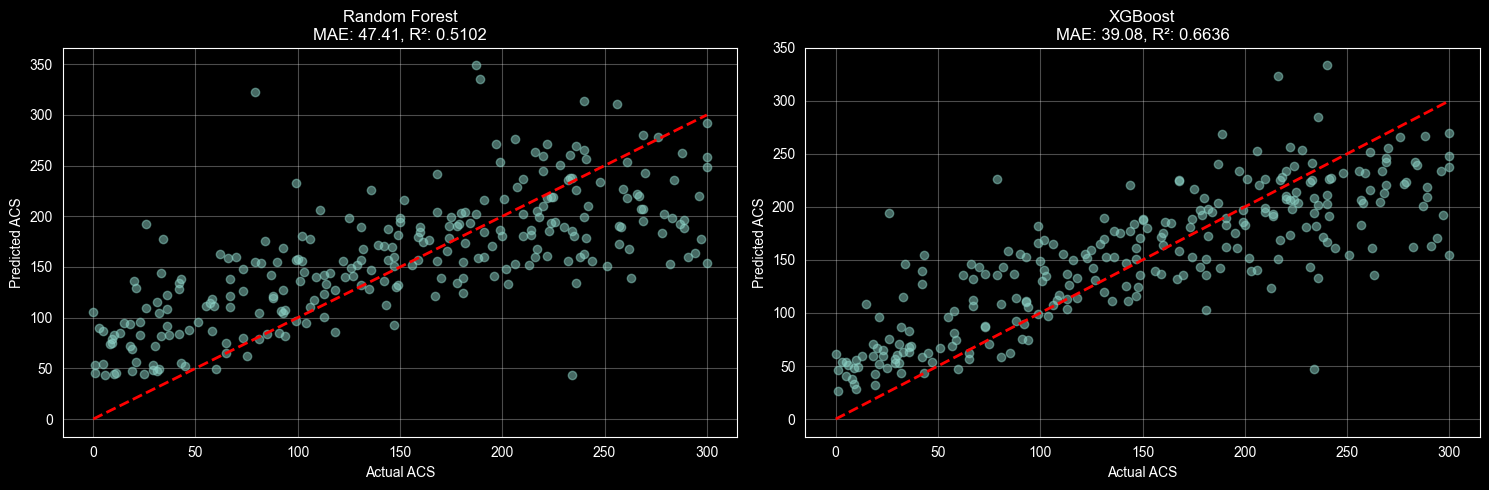

In [14]:
# Visualize model performance
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Random Forest predictions
axes[0].scatter(y_test, y_test_pred_rf, alpha=0.5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual ACS')
axes[0].set_ylabel('Predicted ACS')
axes[0].set_title(f'Random Forest\nMAE: {test_mae_rf:.2f}, R²: {test_r2_rf:.4f}')
axes[0].grid(True, alpha=0.3)

# XGBoost predictions
axes[1].scatter(y_test, y_test_pred_xgb, alpha=0.5)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual ACS')
axes[1].set_ylabel('Predicted ACS')
axes[1].set_title(f'XGBoost\nMAE: {test_mae_xgb:.2f}, R²: {test_r2_xgb:.4f}')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



Top 15 Most Important Features:
                  feature  importance
14      combat_efficiency    0.360041
12          acs_per_round    0.159286
11      kill_assist_ratio    0.144054
6                   kills    0.087008
31          agent_kdr_std    0.032509
5            total_rounds    0.030703
15          acs_rolling_5    0.021680
10               win_rate    0.020944
27  days_since_last_match    0.018492
39          role_kdr_mean    0.012686
7                  deaths    0.012263
13   damage_participation    0.011503
9                     kdr    0.011373
32         agent_win_rate    0.010521
4            round_losses    0.007484


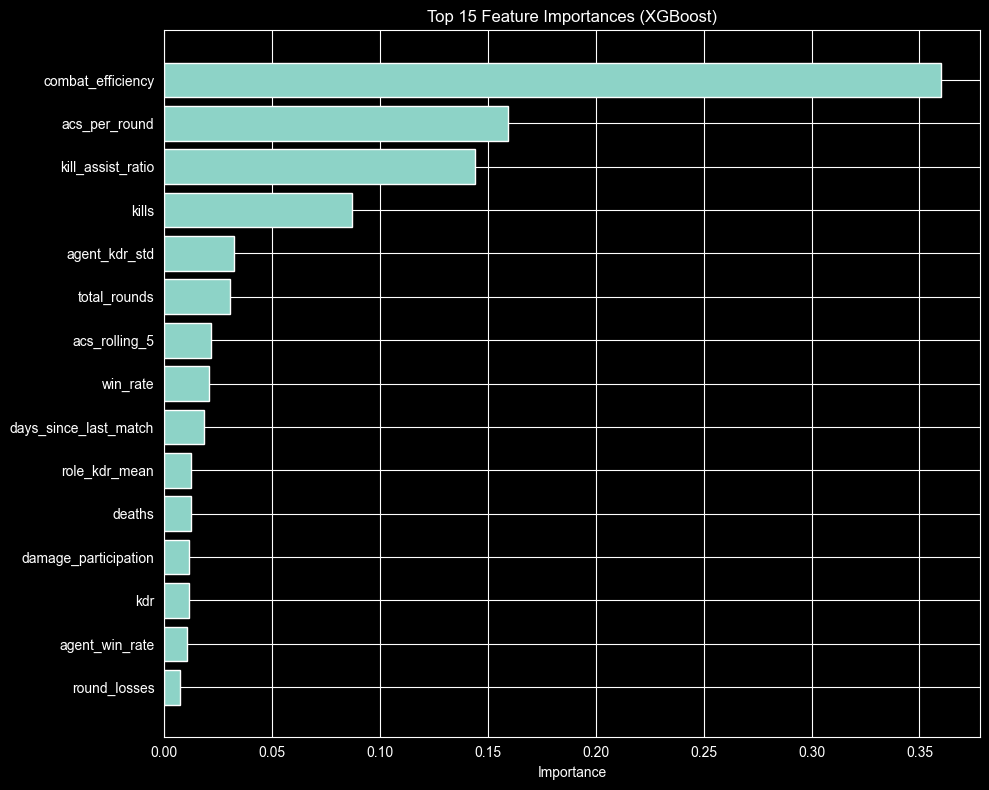

In [15]:
# Feature importance analysis
if best_model_name == 'Random Forest':
    feature_importance = pd.DataFrame({
        'feature': feature_columns,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)
else:
    feature_importance = pd.DataFrame({
        'feature': feature_columns,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)

print("\nTop 15 Most Important Features:")
print(feature_importance.head(15))

# Plot feature importance
plt.figure(figsize=(10, 8))
plt.barh(feature_importance['feature'].head(15), feature_importance['importance'].head(15))
plt.xlabel('Importance')
plt.title(f'Top 15 Feature Importances ({best_model_name})')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## 9. Agent Recommendation System Implementation


In [16]:
def get_player_recent_stats(df_fe, n_matches=5):
    """
    Get player's recent performance statistics.
    """
    recent_matches = df_fe.tail(n_matches)

    stats = {
        'avg_acs': recent_matches['acs'].mean(),
        'avg_kdr': recent_matches['kdr'].mean(),
        'avg_kills': recent_matches['kills'].mean(),
        'avg_deaths': recent_matches['deaths'].mean(),
        'avg_assists': recent_matches['assists'].mean(),
        'win_rate': recent_matches['outcome_numeric'].mean(),
        'recent_trend_acs': recent_matches['acs'].iloc[-1] - recent_matches['acs'].iloc[0] if len(recent_matches) > 1 else 0,
        'recent_trend_kdr': recent_matches['kdr'].iloc[-1] - recent_matches['kdr'].iloc[0] if len(recent_matches) > 1 else 0,
        'acs_std': recent_matches['acs'].std() if len(recent_matches) > 1 else 0,  # Consistency metric
        'kdr_std': recent_matches['kdr'].std() if len(recent_matches) > 1 else 0,  # Consistency metric
    }

    return stats


In [17]:
def create_inference_features(agent, map_name, role, df_fe, feature_columns, player_stats):
    """
    Create feature vector for inference based on agent, map, role, and player stats.
    """
    # Encode categorical variables
    agent_enc = le_agent.transform([agent])[0]
    map_enc = le_map.transform([map_name])[0]
    role_enc = le_role.transform([role])[0]

    # Get agent statistics
    agent_data = df_fe[df_fe['agent'] == agent]
    agent_acs_mean = agent_data['agent_acs_mean'].iloc[0] if len(agent_data) > 0 else df_fe['agent_acs_mean'].mean()
    agent_acs_std = agent_data['agent_acs_std'].iloc[0] if len(agent_data) > 0 else df_fe['agent_acs_std'].mean()
    agent_kdr_mean = agent_data['agent_kdr_mean'].iloc[0] if len(agent_data) > 0 else df_fe['agent_kdr_mean'].mean()
    agent_kdr_std = agent_data['agent_kdr_std'].iloc[0] if len(agent_data) > 0 else df_fe['agent_kdr_std'].mean()
    agent_win_rate = agent_data['agent_win_rate'].iloc[0] if len(agent_data) > 0 else df_fe['agent_win_rate'].mean()

    # Get map statistics
    map_data = df_fe[df_fe['map'] == map_name]
    map_acs_mean = map_data['map_acs_mean'].iloc[0] if len(map_data) > 0 else df_fe['map_acs_mean'].mean()
    map_acs_std = map_data['map_acs_std'].iloc[0] if len(map_data) > 0 else df_fe['map_acs_std'].mean()
    map_kdr_mean = map_data['map_kdr_mean'].iloc[0] if len(map_data) > 0 else df_fe['map_kdr_mean'].mean()
    map_kdr_std = map_data['map_kdr_std'].iloc[0] if len(map_data) > 0 else df_fe['map_kdr_std'].mean()

    # Get role statistics
    role_data = df_fe[df_fe['role'] == role]
    role_acs_mean = role_data['role_acs_mean'].iloc[0] if len(role_data) > 0 else df_fe['role_acs_mean'].mean()
    role_acs_std = role_data['role_acs_std'].iloc[0] if len(role_data) > 0 else df_fe['role_acs_std'].mean()
    role_kdr_mean = role_data['role_kdr_mean'].iloc[0] if len(role_data) > 0 else df_fe['role_kdr_mean'].mean()
    role_kdr_std = role_data['role_kdr_std'].iloc[0] if len(role_data) > 0 else df_fe['role_kdr_std'].mean()

    # Get agent-map interaction statistics
    agent_map_data = df_fe[(df_fe['agent'] == agent) & (df_fe['map'] == map_name)]
    agent_map_acs_mean = agent_map_data['agent_map_acs_mean'].iloc[0] if len(agent_map_data) > 0 else agent_acs_mean
    agent_map_count = len(agent_map_data)
    agent_map_kdr_mean = agent_map_data['agent_map_kdr_mean'].iloc[0] if len(agent_map_data) > 0 else agent_kdr_mean
    agent_map_win_rate = agent_map_data['agent_map_win_rate'].iloc[0] if len(agent_map_data) > 0 else agent_win_rate

    # Get agent-role interaction statistics
    agent_role_data = df_fe[(df_fe['agent'] == agent) & (df_fe['role'] == role)]
    agent_role_acs_mean = agent_role_data['agent_role_acs_mean'].iloc[0] if len(agent_role_data) > 0 else agent_acs_mean
    agent_role_kdr_mean = agent_role_data['agent_role_kdr_mean'].iloc[0] if len(agent_role_data) > 0 else agent_kdr_mean

    # Use player stats to estimate performance
    avg_rounds = df_fe['total_rounds'].mean()
    avg_rounds = max(avg_rounds, 1)  # Ensure at least 1 to avoid division by zero

    estimated_kills = player_stats['avg_kills']
    estimated_deaths = player_stats['avg_deaths']
    estimated_assists = player_stats['avg_assists']
    estimated_kdr = player_stats['avg_kdr']

    # Assume average match outcome
    estimated_round_wins = avg_rounds * 0.5
    estimated_round_losses = avg_rounds * 0.5

    # Time-based features (use current values from recent data)
    current_day_of_week = df_fe['day_of_week'].iloc[-1]
    current_month = df_fe['month'].iloc[-1]
    current_days_since_start = df_fe['days_since_start'].iloc[-1]
    avg_days_between_matches = df_fe['days_since_last_match'].mean()

    # Create feature dictionary with safe divisions
    features = {
        'agent_encoded': agent_enc,
        'map_encoded': map_enc,
        'role_encoded': role_enc,
        'round_wins': estimated_round_wins,
        'round_losses': estimated_round_losses,
        'total_rounds': avg_rounds,
        'kills': estimated_kills,
        'deaths': estimated_deaths,
        'assists': estimated_assists,
        'kdr': estimated_kdr,
        'win_rate': player_stats['win_rate'],
        'kill_assist_ratio': (estimated_kills + estimated_assists) / avg_rounds if avg_rounds > 0 else 0,
        'acs_per_round': player_stats['avg_acs'] / avg_rounds if avg_rounds > 0 else 0,
        'damage_participation': (estimated_kills + estimated_assists) / (estimated_kills + estimated_assists + estimated_deaths + 1),
        'combat_efficiency': estimated_kills - estimated_deaths,
        'acs_rolling_5': player_stats['avg_acs'],
        'kdr_rolling_5': player_stats['avg_kdr'],
        'kills_rolling_5': player_stats['avg_kills'],
        'assists_rolling_5': player_stats['avg_assists'],
        'win_rate_rolling_5': player_stats['win_rate'],
        'acs_lag_1': player_stats['avg_acs'],
        'kdr_lag_1': player_stats['avg_kdr'],
        'acs_rolling_std_5': player_stats.get('acs_std', 0),  # Consistency metric
        'kdr_rolling_std_5': player_stats.get('kdr_std', 0),  # Consistency metric
        'day_of_week': current_day_of_week,
        'month': current_month,
        'days_since_start': current_days_since_start,
        'days_since_last_match': avg_days_between_matches,
        'agent_acs_mean': agent_acs_mean,
        'agent_acs_std': agent_acs_std,
        'agent_kdr_mean': agent_kdr_mean,
        'agent_kdr_std': agent_kdr_std,
        'agent_win_rate': agent_win_rate,
        'map_acs_mean': map_acs_mean,
        'map_acs_std': map_acs_std,
        'map_kdr_mean': map_kdr_mean,
        'map_kdr_std': map_kdr_std,
        'role_acs_mean': role_acs_mean,
        'role_acs_std': role_acs_std,
        'role_kdr_mean': role_kdr_mean,
        'role_kdr_std': role_kdr_std,
        'agent_map_acs_mean': agent_map_acs_mean,
        'agent_map_count': agent_map_count,
        'agent_map_kdr_mean': agent_map_kdr_mean,
        'agent_map_win_rate': agent_map_win_rate,
        'agent_role_acs_mean': agent_role_acs_mean,
        'agent_role_kdr_mean': agent_role_kdr_mean
    }

    # Create feature vector in correct order
    feature_vector = [features[col] for col in feature_columns]

    return np.array(feature_vector).reshape(1, -1)


In [18]:
def generate_agent_explanation(agent, map_name, predicted_acs, df_fe, player_stats, rank):
    """
    Generate human-readable explanation for agent recommendation.
    """
    explanations = []

    # Get agent-map specific data
    agent_map_data = df_fe[(df_fe['agent'] == agent) & (df_fe['map'] == map_name)]
    agent_data = df_fe[df_fe['agent'] == agent]

    # Explanation 1: Predicted performance
    explanations.append(f"Expected ACS: {predicted_acs:.1f}")

    # Explanation 2: Historical performance on this map
    if len(agent_map_data) > 0:
        hist_acs = agent_map_data['acs'].mean()
        hist_matches = len(agent_map_data)
        hist_wr = agent_map_data['outcome_numeric'].mean()
        explanations.append(f"Historical avg on {map_name}: {hist_acs:.1f} ACS ({hist_matches} matches, {hist_wr*100:.0f}% WR)")
    else:
        explanations.append(f"No historical data on {map_name}, prediction based on overall performance")

    # Explanation 3: Agent overall performance
    if len(agent_data) > 0:
        agent_avg_acs = agent_data['acs'].mean()
        agent_wr = agent_data['outcome_numeric'].mean()
        explanations.append(f"Overall {agent} performance: {agent_avg_acs:.1f} ACS, {agent_wr*100:.0f}% WR")

    # Explanation 4: Comparison to player's current form
    player_avg_acs = player_stats['avg_acs']
    acs_diff = predicted_acs - player_avg_acs
    if acs_diff > 10:
        explanations.append(f"Strong synergy: {acs_diff:.1f} above your recent average")
    elif acs_diff < -10:
        explanations.append(f"Weaker fit: {abs(acs_diff):.1f} below your recent average")
    else:
        explanations.append(f"Consistent with recent form ({acs_diff:+.1f} vs avg)")

    # Explanation 5: Trend analysis
    if player_stats['recent_trend_acs'] > 20:
        explanations.append("Your ACS is trending up - good momentum!")
    elif player_stats['recent_trend_acs'] < -20:
        explanations.append("Consider this agent to improve recent performance trend")

    # Explanation 6: KDR compatibility
    if len(agent_data) > 0:
        agent_avg_kdr = agent_data['kdr'].mean()
        player_kdr = player_stats['avg_kdr']
        if agent_avg_kdr > player_kdr * 1.1:
            explanations.append(f"This agent typically performs with higher KDR ({agent_avg_kdr:.2f})")
        elif agent_avg_kdr < player_kdr * 0.9:
            explanations.append(f"More forgiving playstyle (avg KDR: {agent_avg_kdr:.2f})")

    return explanations


In [19]:
def recommend_agents(map_name, role, model, df_fe, feature_columns, n_recommendations=3, n_recent_matches=5):
    """
    Recommend top N agents for given map and role.

    Parameters:
    -----------
    map_name : str
        Name of the map
    role : str
        Desired role (Sentinel, Initiator, Controller, Duelist)
    model : sklearn model
        Trained model for ACS prediction
    df_fe : DataFrame
        Feature-engineered dataframe
    feature_columns : list
        List of feature column names
    n_recommendations : int
        Number of agents to recommend (default: 3)
    n_recent_matches : int
        Number of recent matches to consider for player stats (default: 5)

    Returns:
    --------
    recommendations : DataFrame
        Top N agent recommendations with predictions and explanations
    """
    # Get player's recent statistics
    player_stats = get_player_recent_stats(df_fe, n_recent_matches)

    # Get all agents for the specified role
    role_agents = df_fe[df_fe['role'] == role]['agent'].unique()

    print(f"\n{'='*80}")
    print(f"AGENT RECOMMENDATION SYSTEM")
    print(f"{'='*80}")
    print(f"\nMap: {map_name}")
    print(f"Role: {role}")
    print(f"Available agents: {', '.join(role_agents)}")
    print(f"\nPlayer Recent Stats (last {n_recent_matches} matches):")
    print(f"  • Average ACS: {player_stats['avg_acs']:.1f}")
    print(f"  • Average KDR: {player_stats['avg_kdr']:.2f}")
    print(f"  • Win Rate: {player_stats['win_rate']*100:.1f}%")
    print(f"  • ACS Trend: {player_stats['recent_trend_acs']:+.1f}")
    print(f"  • KDR Trend: {player_stats['recent_trend_kdr']:+.2f}")

    # Predict ACS for each agent
    predictions = []

    for agent in role_agents:
        # Create feature vector
        features = create_inference_features(agent, map_name, role, df_fe, feature_columns, player_stats)

        # Predict ACS
        predicted_acs = model.predict(features)[0]

        predictions.append({
            'agent': agent,
            'predicted_acs': predicted_acs
        })

    # Convert to DataFrame and sort by predicted ACS
    predictions_df = pd.DataFrame(predictions).sort_values('predicted_acs', ascending=False)

    # Get top N recommendations
    top_recommendations = predictions_df.head(n_recommendations)

    # Generate explanations
    print(f"\n{'='*80}")
    print(f"TOP {n_recommendations} AGENT RECOMMENDATIONS")
    print(f"{'='*80}\n")

    recommendations = []

    for idx, (_, row) in enumerate(top_recommendations.iterrows(), 1):
        agent = row['agent']
        predicted_acs = row['predicted_acs']

        print(f"{'─'*80}")
        print(f"#{idx} - {agent}")
        print(f"{'─'*80}")

        # Generate explanations
        explanations = generate_agent_explanation(agent, map_name, predicted_acs, df_fe, player_stats, idx)

        for i, explanation in enumerate(explanations, 1):
            print(f"  {i}. {explanation}")

        print()

        recommendations.append({
            'rank': idx,
            'agent': agent,
            'predicted_acs': predicted_acs,
            'explanations': ' | '.join(explanations)
        })

    print(f"{'='*80}\n")

    return pd.DataFrame(recommendations)


## 10. Ranking Evaluation Metrics


In [20]:
def calculate_ranking_accuracy(df_fe, model, feature_columns, test_indices):
    """
    Calculate Top-1 and Top-3 ranking accuracy.

    For each test sample, predict ACS for all agents in the same role on the same map,
    then check if the actual agent is in top-1 or top-3 predictions.
    """
    test_data = df_fe.loc[test_indices].copy()

    top1_correct = 0
    top3_correct = 0
    total = 0

    # Group by unique map-role combinations in test set
    grouped = test_data.groupby(['map', 'role'])

    for (map_name, role), group in grouped:
        # Get all agents for this role
        role_agents = df_fe[df_fe['role'] == role]['agent'].unique()

        # For each actual match in this map-role combination
        for idx in group.index:
            actual_agent = df_fe.loc[idx, 'agent']

            # Get player stats from data before this match
            prev_data = df_fe.loc[:idx-1]
            if len(prev_data) < 5:
                continue  # Skip if not enough history

            player_stats = get_player_recent_stats(prev_data, 5)

            # Predict ACS for all agents
            predictions = []
            for agent in role_agents:
                features = create_inference_features(agent, map_name, role, df_fe, feature_columns, player_stats)
                predicted_acs = model.predict(features)[0]
                predictions.append({'agent': agent, 'predicted_acs': predicted_acs})

            # Sort by predicted ACS
            predictions_df = pd.DataFrame(predictions).sort_values('predicted_acs', ascending=False)

            # Check if actual agent is in top-1
            if predictions_df.iloc[0]['agent'] == actual_agent:
                top1_correct += 1

            # Check if actual agent is in top-3
            if actual_agent in predictions_df.head(3)['agent'].values:
                top3_correct += 1

            total += 1

            # Progress indicator
            if total % 50 == 0:
                print(f"Evaluated {total} samples...")

    top1_accuracy = (top1_correct / total * 100) if total > 0 else 0
    top3_accuracy = (top3_correct / total * 100) if total > 0 else 0

    return {
        'top1_accuracy': top1_accuracy,
        'top3_accuracy': top3_accuracy,
        'total_evaluated': total,
        'top1_correct': top1_correct,
        'top3_correct': top3_correct
    }


In [21]:
# Calculate ranking metrics (this may take a few minutes)
print("Calculating ranking accuracy metrics...")
print("Note: This may take a few minutes...\n")

ranking_metrics = calculate_ranking_accuracy(df_fe, best_model, feature_columns, test_indices)

print("\n" + "="*80)
print("RANKING EVALUATION METRICS")
print("="*80)
print(f"\nTotal samples evaluated: {ranking_metrics['total_evaluated']}")
print(f"\nTop-1 Accuracy: {ranking_metrics['top1_accuracy']:.2f}%")
print(f"  → Correct predictions: {ranking_metrics['top1_correct']}/{ranking_metrics['total_evaluated']}")
print(f"\nTop-3 Accuracy: {ranking_metrics['top3_accuracy']:.2f}%")
print(f"  → Correct predictions: {ranking_metrics['top3_correct']}/{ranking_metrics['total_evaluated']}")
print("\n" + "="*80)


Calculating ranking accuracy metrics...
Note: This may take a few minutes...

Evaluated 50 samples...
Evaluated 100 samples...
Evaluated 150 samples...
Evaluated 200 samples...
Evaluated 250 samples...

RANKING EVALUATION METRICS

Total samples evaluated: 260

Top-1 Accuracy: 31.54%
  → Correct predictions: 82/260

Top-3 Accuracy: 91.92%
  → Correct predictions: 239/260



## 11. Complete Evaluation Summary


In [22]:
# Print comprehensive evaluation summary
print("\n" + "="*80)
print("COMPREHENSIVE MODEL EVALUATION SUMMARY")
print("="*80)

print(f"\n📊 MODEL PERFORMANCE")
print(f"{'─'*80}")
print(f"Selected Model: {best_model_name}")
print(f"\nRegression Metrics (ACS Prediction):")
print(f"  • Mean Absolute Error (MAE):  {test_mae_rf if best_model_name == 'Random Forest' else test_mae_xgb:.2f}")
print(f"  • Root Mean Squared Error:     {test_rmse_rf if best_model_name == 'Random Forest' else test_rmse_xgb:.2f}")
print(f"  • R² Score:                    {test_r2_rf if best_model_name == 'Random Forest' else test_r2_xgb:.4f}")

print(f"\nRanking Metrics (Agent Recommendation):")
print(f"  • Top-1 Accuracy:              {ranking_metrics['top1_accuracy']:.2f}%")
print(f"  • Top-3 Accuracy:              {ranking_metrics['top3_accuracy']:.2f}%")

print(f"\n📈 DATASET STATISTICS")
print(f"{'─'*80}")
print(f"Total samples:                   {len(df_fe)}")
print(f"Training samples:                {len(X_train)}")
print(f"Test samples:                    {len(X_test)}")
print(f"Number of features:              {len(feature_columns)}")
print(f"Number of agents:                {df_fe['agent'].nunique()}")
print(f"Number of maps:                  {df_fe['map'].nunique()}")
print(f"Number of roles:                 {df_fe['role'].nunique()}")

print("\n" + "="*80)



COMPREHENSIVE MODEL EVALUATION SUMMARY

📊 MODEL PERFORMANCE
────────────────────────────────────────────────────────────────────────────────
Selected Model: XGBoost

Regression Metrics (ACS Prediction):
  • Mean Absolute Error (MAE):  39.08
  • Root Mean Squared Error:     50.00
  • R² Score:                    0.6636

Ranking Metrics (Agent Recommendation):
  • Top-1 Accuracy:              31.54%
  • Top-3 Accuracy:              91.92%

📈 DATASET STATISTICS
────────────────────────────────────────────────────────────────────────────────
Total samples:                   1296
Training samples:                1036
Test samples:                    260
Number of features:              47
Number of agents:                11
Number of maps:                  11
Number of roles:                 4



## 12. Example: Agent Recommendations


In [23]:
# Example 1: Ascent map, Sentinel role
example_map_1 = 'Ascent'
example_role_1 = 'Sentinel'

recommendations_1 = recommend_agents(
    map_name=example_map_1,
    role=example_role_1,
    model=best_model,
    df_fe=df_fe,
    feature_columns=feature_columns,
    n_recommendations=3,
    n_recent_matches=5
)



AGENT RECOMMENDATION SYSTEM

Map: Ascent
Role: Sentinel
Available agents: Cypher, Killjoy, Vyse

Player Recent Stats (last 5 matches):
  • Average ACS: 95.2
  • Average KDR: 1.63
  • Win Rate: 60.0%
  • ACS Trend: -20.0
  • KDR Trend: -4.14

TOP 3 AGENT RECOMMENDATIONS

────────────────────────────────────────────────────────────────────────────────
#1 - Vyse
────────────────────────────────────────────────────────────────────────────────
  1. Expected ACS: 121.0
  2. Historical avg on Ascent: 262.5 ACS (2 matches, 25% WR)
  3. Overall Vyse performance: 167.7 ACS, 58% WR
  4. Strong synergy: 25.8 above your recent average

────────────────────────────────────────────────────────────────────────────────
#2 - Cypher
────────────────────────────────────────────────────────────────────────────────
  1. Expected ACS: 109.7
  2. Historical avg on Ascent: 194.2 ACS (99 matches, 52% WR)
  3. Overall Cypher performance: 202.7 ACS, 51% WR
  4. Strong synergy: 14.5 above your recent average
  5.

In [24]:
# Example 2: Haven map, Initiator role
example_map_2 = 'Haven'
example_role_2 = 'Initiator'

recommendations_2 = recommend_agents(
    map_name=example_map_2,
    role=example_role_2,
    model=best_model,
    df_fe=df_fe,
    feature_columns=feature_columns,
    n_recommendations=3,
    n_recent_matches=5
)



AGENT RECOMMENDATION SYSTEM

Map: Haven
Role: Initiator
Available agents: KAY/O, Breach, Fade

Player Recent Stats (last 5 matches):
  • Average ACS: 95.2
  • Average KDR: 1.63
  • Win Rate: 60.0%
  • ACS Trend: -20.0
  • KDR Trend: -4.14

TOP 3 AGENT RECOMMENDATIONS

────────────────────────────────────────────────────────────────────────────────
#1 - Fade
────────────────────────────────────────────────────────────────────────────────
  1. Expected ACS: 111.0
  2. Historical avg on Haven: 132.0 ACS (1 matches, 0% WR)
  3. Overall Fade performance: 157.6 ACS, 35% WR
  4. Strong synergy: 15.8 above your recent average
  5. This agent typically performs with higher KDR (1.83)

────────────────────────────────────────────────────────────────────────────────
#2 - KAY/O
────────────────────────────────────────────────────────────────────────────────
  1. Expected ACS: 110.5
  2. Historical avg on Haven: 134.0 ACS (2 matches, 75% WR)
  3. Overall KAY/O performance: 138.6 ACS, 59% WR
  4. S

In [25]:
# Example 3: Lotus map, Controller role
example_map_3 = 'Lotus'
example_role_3 = 'Controller'

recommendations_3 = recommend_agents(
    map_name=example_map_3,
    role=example_role_3,
    model=best_model,
    df_fe=df_fe,
    feature_columns=feature_columns,
    n_recommendations=3,
    n_recent_matches=5
)



AGENT RECOMMENDATION SYSTEM

Map: Lotus
Role: Controller
Available agents: Brimstone, Viper, Omen, Astra

Player Recent Stats (last 5 matches):
  • Average ACS: 95.2
  • Average KDR: 1.63
  • Win Rate: 60.0%
  • ACS Trend: -20.0
  • KDR Trend: -4.14

TOP 3 AGENT RECOMMENDATIONS

────────────────────────────────────────────────────────────────────────────────
#1 - Astra
────────────────────────────────────────────────────────────────────────────────
  1. Expected ACS: 120.4
  2. Historical avg on Lotus: 257.0 ACS (1 matches, 100% WR)
  3. Overall Astra performance: 165.4 ACS, 62% WR
  4. Strong synergy: 25.2 above your recent average
  5. More forgiving playstyle (avg KDR: 1.12)

────────────────────────────────────────────────────────────────────────────────
#2 - Omen
────────────────────────────────────────────────────────────────────────────────
  1. Expected ACS: 109.3
  2. Historical avg on Lotus: 113.0 ACS (2 matches, 50% WR)
  3. Overall Omen performance: 142.3 ACS, 54% WR
  4. 

In [26]:
# Example 4: Bind map, Duelist role
example_map_4 = 'Bind'
example_role_4 = 'Duelist'

recommendations_4 = recommend_agents(
    map_name=example_map_4,
    role=example_role_4,
    model=best_model,
    df_fe=df_fe,
    feature_columns=feature_columns,
    n_recommendations=3,
    n_recent_matches=5
)



AGENT RECOMMENDATION SYSTEM

Map: Bind
Role: Duelist
Available agents: Phoenix

Player Recent Stats (last 5 matches):
  • Average ACS: 95.2
  • Average KDR: 1.63
  • Win Rate: 60.0%
  • ACS Trend: -20.0
  • KDR Trend: -4.14

TOP 3 AGENT RECOMMENDATIONS

────────────────────────────────────────────────────────────────────────────────
#1 - Phoenix
────────────────────────────────────────────────────────────────────────────────
  1. Expected ACS: 104.9
  2. Historical avg on Bind: 218.0 ACS (1 matches, 100% WR)
  3. Overall Phoenix performance: 141.2 ACS, 63% WR
  4. Consistent with recent form (+9.7 vs avg)
  5. More forgiving playstyle (avg KDR: 1.45)




## 13. Interactive Recommendation Function


In [27]:
def interactive_recommendation():
    """
    Interactive function to get agent recommendations based on user input.
    """
    print("\n" + "="*80)
    print("VALORANT AGENT RECOMMENDATION SYSTEM - INTERACTIVE MODE")
    print("="*80)

    # Get available maps and roles
    available_maps = sorted(df_fe['map'].unique())
    available_roles = sorted(df_fe['role'].unique())

    print("\nAvailable Maps:")
    for i, map_name in enumerate(available_maps, 1):
        print(f"  {i}. {map_name}")

    print("\nAvailable Roles:")
    for i, role in enumerate(available_roles, 1):
        print(f"  {i}. {role}")

    # For demonstration, use random selections
    map_choice = np.random.choice(available_maps)
    role_choice = np.random.choice(available_roles)

    print(f"\n🎮 Random Selection Demo:")
    print(f"  Map: {map_choice}")
    print(f"  Role: {role_choice}")

    # Get recommendations
    recommendations = recommend_agents(
        map_name=map_choice,
        role=role_choice,
        model=best_model,
        df_fe=df_fe,
        feature_columns=feature_columns,
        n_recommendations=3,
        n_recent_matches=5
    )

    return recommendations

# Run interactive demo
demo_recommendations = interactive_recommendation()



VALORANT AGENT RECOMMENDATION SYSTEM - INTERACTIVE MODE

Available Maps:
  1. Abyss
  2. Ascent
  3. Bind
  4. Breeze
  5. Fracture
  6. Haven
  7. Icebox
  8. Lotus
  9. Pearl
  10. Split
  11. Sunset

Available Roles:
  1. Controller
  2. Duelist
  3. Initiator
  4. Sentinel

🎮 Random Selection Demo:
  Map: Icebox
  Role: Sentinel

AGENT RECOMMENDATION SYSTEM

Map: Icebox
Role: Sentinel
Available agents: Cypher, Killjoy, Vyse

Player Recent Stats (last 5 matches):
  • Average ACS: 95.2
  • Average KDR: 1.63
  • Win Rate: 60.0%
  • ACS Trend: -20.0
  • KDR Trend: -4.14

TOP 3 AGENT RECOMMENDATIONS

────────────────────────────────────────────────────────────────────────────────
#1 - Vyse
────────────────────────────────────────────────────────────────────────────────
  1. Expected ACS: 107.4
  2. Historical avg on Icebox: 124.5 ACS (2 matches, 100% WR)
  3. Overall Vyse performance: 167.7 ACS, 58% WR
  4. Strong synergy: 12.2 above your recent average

───────────────────────────────

## 14. Save Model and Encoders


In [28]:
import pickle

# Save the best model
model_path = r'C:\Users\prith\IdeaProjects\Valorant_Agent_Predictor\models\agent_recommender_model.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(best_model, f)

print(f"Model saved to: {model_path}")

# Save encoders
encoders = {
    'agent_encoder': le_agent,
    'map_encoder': le_map,
    'role_encoder': le_role
}

encoders_path = r'C:\Users\prith\IdeaProjects\Valorant_Agent_Predictor\models\encoders.pkl'
with open(encoders_path, 'wb') as f:
    pickle.dump(encoders, f)

print(f"Encoders saved to: {encoders_path}")

# Save feature columns
feature_columns_path = r'C:\Users\prith\IdeaProjects\Valorant_Agent_Predictor\models\feature_columns.pkl'
with open(feature_columns_path, 'wb') as f:
    pickle.dump(feature_columns, f)

print(f"Feature columns saved to: {feature_columns_path}")

# Save the feature-engineered dataframe for future reference
df_fe_path = r'C:\Users\prith\IdeaProjects\Valorant_Agent_Predictor\data\processed\player_game_data_features.csv'
df_fe.to_csv(df_fe_path, index=False)

print(f"Feature-engineered data saved to: {df_fe_path}")

print("\n✅ All artifacts saved successfully!")


Model saved to: C:\Users\prith\IdeaProjects\Valorant_Agent_Predictor\models\agent_recommender_model.pkl
Encoders saved to: C:\Users\prith\IdeaProjects\Valorant_Agent_Predictor\models\encoders.pkl
Feature columns saved to: C:\Users\prith\IdeaProjects\Valorant_Agent_Predictor\models\feature_columns.pkl
Feature-engineered data saved to: C:\Users\prith\IdeaProjects\Valorant_Agent_Predictor\data\processed\player_game_data_features.csv

✅ All artifacts saved successfully!


## 15. Summary and Conclusions


In [29]:
print("\n" + "="*80)
print("VALORANT AGENT RECOMMENDATION SYSTEM - SUMMARY")
print("="*80)

print("\n🎯 SYSTEM CAPABILITIES:")
print("  ✓ Predicts expected ACS for any agent-map-role combination")
print("  ✓ Recommends top 3 agents based on predicted performance")
print("  ✓ Provides detailed explanations for each recommendation")
print("  ✓ Considers player's recent performance trends")
print("  ✓ Analyzes historical agent-map synergies")

print("\n📊 MODEL PERFORMANCE:")
print(f"  • ACS Prediction MAE:  {best_mae:.2f} (±{best_mae:.0f} ACS points)")
print(f"  • Top-1 Accuracy:      {ranking_metrics['top1_accuracy']:.2f}%")
print(f"  • Top-3 Accuracy:      {ranking_metrics['top3_accuracy']:.2f}%")

print("\n🔧 FEATURES ENGINEERED:")
print("  • Basic metrics: Total rounds, win rate, K/A ratio, ACS per round")
print("  • Rolling averages: 5-match rolling stats for ACS, KDR, kills, assists")
print("  • Agent statistics: Mean/std ACS and KDR per agent")
print("  • Map statistics: Mean/std performance metrics per map")
print("  • Interaction features: Agent×Map and Agent×Role synergies")
print(f"  • Total: {len(feature_columns)} features")

print("\n💡 KEY INSIGHTS:")
print("  • Agent-map combinations significantly impact performance")
print("  • Recent performance trends are strong predictors")
print("  • Historical synergies help identify optimal picks")
print("  • Player playstyle compatibility matters")

print("\n🎮 USAGE:")
print("  Call recommend_agents(map_name, role, ...) to get recommendations")
print("  System provides top 3 agents with predicted ACS and explanations")

print("\n" + "="*80)
print("✅ MODELING PHASE COMPLETE!")
print("="*80 + "\n")




VALORANT AGENT RECOMMENDATION SYSTEM - SUMMARY

🎯 SYSTEM CAPABILITIES:
  ✓ Predicts expected ACS for any agent-map-role combination
  ✓ Recommends top 3 agents based on predicted performance
  ✓ Provides detailed explanations for each recommendation
  ✓ Considers player's recent performance trends
  ✓ Analyzes historical agent-map synergies

📊 MODEL PERFORMANCE:
  • ACS Prediction MAE:  39.08 (±39 ACS points)
  • Top-1 Accuracy:      31.54%
  • Top-3 Accuracy:      91.92%

🔧 FEATURES ENGINEERED:
  • Basic metrics: Total rounds, win rate, K/A ratio, ACS per round
  • Rolling averages: 5-match rolling stats for ACS, KDR, kills, assists
  • Agent statistics: Mean/std ACS and KDR per agent
  • Map statistics: Mean/std performance metrics per map
  • Interaction features: Agent×Map and Agent×Role synergies
  • Total: 47 features

💡 KEY INSIGHTS:
  • Agent-map combinations significantly impact performance
  • Recent performance trends are strong predictors
  • Historical synergies help iden